In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
data = {
    "Student_ID": list(range(1, 26)),
    "Age": [18, 19, 20, 18, 21, 19, None, 20, 18, 22,
            19, 20, 21, 18, 19, None, 20, 21, 18, 35,
            19, 20, 21, 18, 22],   # 35 as outlier

    "Gender": ["M", "F", "F", "M", "F", "M", "Male", "F", "M", "F",
               "F", "M", "F", "Male", "F", "M", "F", "M", "F", "M",
               "F", "M", "F", "M", "F"],

    "Math_Score": [78, 85, 90, 65, 88, 72, None, 80, 75, 92,
                   89, 84, 91, 60, 77, 82, 86, None, 73, 15,
                   88, 90, 85, 70, 95],   # 15 as outlier

    "Attendance": [85, 90, 88, 75, None, 80, 92, 89, 78, 95,
                   91, 87, 93, 70, 82, 85, None, 90, 76, 40,
                   88, 92, 86, 79, 96]    # 40 as outlier
}


In [35]:
df = pd.DataFrame(data)
df.head()

,Student_ID,Age,Gender,Math_Score,Attendance
0,1,18.0,M,78.0,85.0
1,2,19.0,F,85.0,90.0
2,3,20.0,F,90.0,88.0
3,4,18.0,M,65.0,75.0
4,5,21.0,F,88.0,NaN


In [36]:
df.tail()

,Student_ID,Age,Gender,Math_Score,Attendance
20,21,19.0,F,88.0,88.0
21,22,20.0,M,90.0,92.0
22,23,21.0,F,85.0,86.0
23,24,18.0,M,70.0,79.0
24,25,22.0,F,95.0,96.0


In [37]:
df.sample(5)

,Student_ID,Age,Gender,Math_Score,Attendance
13,14,18.0,Male,60.0,70.0
3,4,18.0,M,65.0,75.0
17,18,21.0,M,NaN,90.0
12,13,21.0,F,91.0,93.0
15,16,NaN,M,82.0,85.0


In [38]:
df['Gender'] = df['Gender'].replace('Male', 'M')
df

,Student_ID,Age,Gender,Math_Score,Attendance
0,1,18.0,M,78.0,85.0
1,2,19.0,F,85.0,90.0
2,3,20.0,F,90.0,88.0
3,4,18.0,M,65.0,75.0
4,5,21.0,F,88.0,NaN
5,6,19.0,M,72.0,80.0
6,7,NaN,M,NaN,92.0
7,8,20.0,F,80.0,89.0
8,9,18.0,M,75.0,78.0
9,10,22.0,F,92.0,95.0


In [39]:
df.isnull().sum()

Student_ID    0
Age           2
Gender        0
Math_Score    2
Attendance    2
dtype: int64

In [40]:
# adding the values in place of the null values
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Math_Score'] = df['Math_Score'].fillna(df['Math_Score'].mean())
df['Attendance'] = df['Attendance'].fillna(df['Attendance'].mean())


In [41]:
# now the null values are 0
df.isnull().sum()

Student_ID    0
Age           0
Gender        0
Math_Score    0
Attendance    0
dtype: int64

In [42]:
# 2. Scan all numeric variables for outliers. If there are outliers, use any of the suitable techniques
# to deal with them.

# detect the numerical data
df.select_dtypes(include=['int64','float64'])

,Student_ID,Age,Math_Score,Attendance
0,1,18.00000,78.000000,85.000000
1,2,19.00000,85.000000,90.000000
2,3,20.00000,90.000000,88.000000
3,4,18.00000,65.000000,75.000000
4,5,21.00000,88.000000,83.782609
5,6,19.00000,72.000000,80.000000
6,7,20.26087,78.695652,92.000000
7,8,20.00000,80.000000,89.000000
8,9,18.00000,75.000000,78.000000
9,10,22.00000,92.000000,95.000000


In [43]:
# apply the outliers on one column

# Step 1: Calculate Q1 and Q3
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

# Step 2: Calculate IQR
IQR = Q3 - Q1

# Step 3: Calculate limits
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower limit :", lower)
print("Upper limit :", upper)


Q1 : 19.0
Q3 : 21.0
IQR : 2.0
Lower limit : 16.0
Upper limit : 24.0


In [44]:
outlier = df[(df['Age'] < lower) | (df['Age'] > upper)]
outlier['Age']

19    35.0
Name: Age, dtype: float64

In [45]:
# apply the outliers on one column

# Step 1: Calculate Q1 and Q3
Q1 = df['Math_Score'].quantile(0.25)
Q3 = df['Math_Score'].quantile(0.75)

# Step 2: Calculate IQR
IQR = Q3 - Q1

# Step 3: Calculate limits
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower limit :", lower)
print("Upper limit :", upper)


Q1 : 75.0
Q3 : 88.0
IQR : 13.0
Lower limit : 55.5
Upper limit : 107.5


In [46]:
outlier = df[(df['Math_Score'] < lower) | (df['Math_Score'] > upper)]
outlier['Math_Score']

19    15.0
Name: Math_Score, dtype: float64

In [47]:
Q1 = df['Attendance'].quantile(0.25)
Q3 = df['Attendance'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower limit :", lower)
print("Upper limit :", upper)

Q1 : 80.0
Q3 : 90.0
IQR : 10.0
Lower limit : 65.0
Upper limit : 105.0


In [48]:
outlier = df[(df['Attendance'] < lower) | (df['Attendance'] > upper)]
outlier['Attendance']

19    40.0
Name: Attendance, dtype: float64

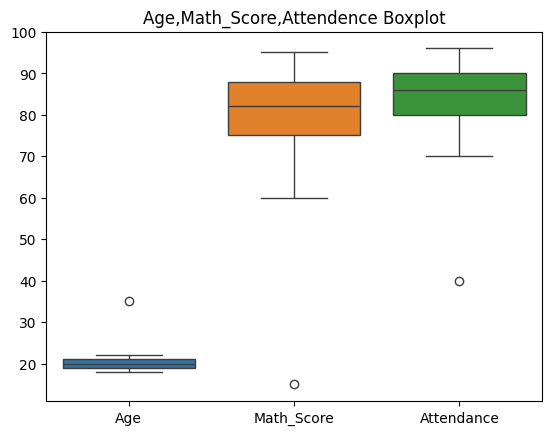

In [49]:
sns.boxplot(df[['Age','Math_Score','Attendance']])
plt.title("Age,Math_Score,Attendence Boxplot")
plt.show()

In [50]:
for column in ['Age', 'Math_Score', 'Attendance']:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[column] = np.where(df[column] < lower, lower,
                          np.where(df[column] > upper, upper,
                                   df[column]))
    df[column]

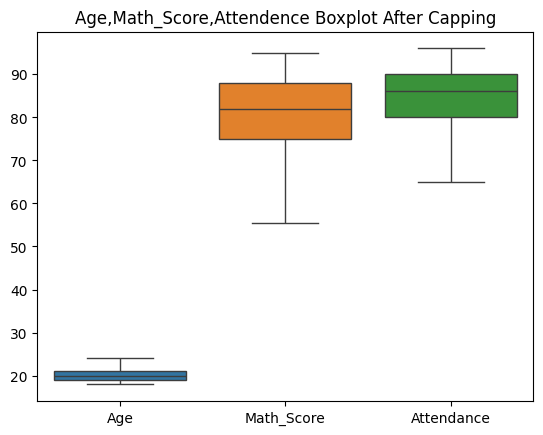

In [51]:
sns.boxplot(df[['Age','Math_Score','Attendance']])
plt.title("Age,Math_Score,Attendence Boxplot After Capping")
plt.show()


In [52]:
X = df[['Age', 'Math_Score', 'Attendance']]

from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, 
                                   test_size=0.2, 
                                   random_state=42)


In [53]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)


In [54]:
import pandas as pd

X_train_scaled = pd.DataFrame(X_train_scaled,
                              columns=['Age','Math_Score','Attendance'])

X_test_scaled = pd.DataFrame(X_test_scaled,
                             columns=['Age','Math_Score','Attendance'])


In [55]:
X_train_scaled.head()


,Age,Math_Score,Attendance
0,0.666667,0.924051,0.967742
1,0.000000,0.113924,0.161290
2,0.166667,0.746835,0.806452
3,0.500000,0.746835,0.677419
4,0.166667,0.417722,0.483871


In [56]:
df[['Age','Math_Score','Attendance']].skew()


Age           0.773932
Math_Score   -0.849435
Attendance   -0.858368
dtype: float64

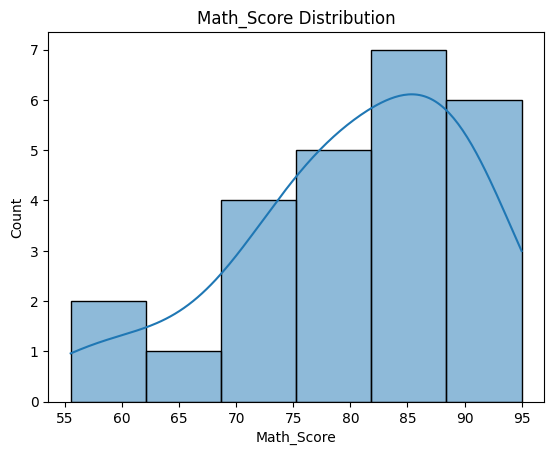

In [57]:
sns.histplot(df['Math_Score'], kde=True)
plt.title("Math_Score Distribution")
plt.show()


<Axes: xlabel='Age', ylabel='Count'>

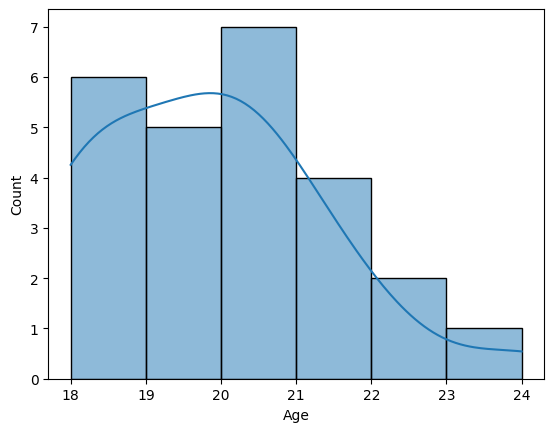

In [58]:
sns.histplot(df['Age'], kde=True)



<Axes: xlabel='Attendance', ylabel='Count'>

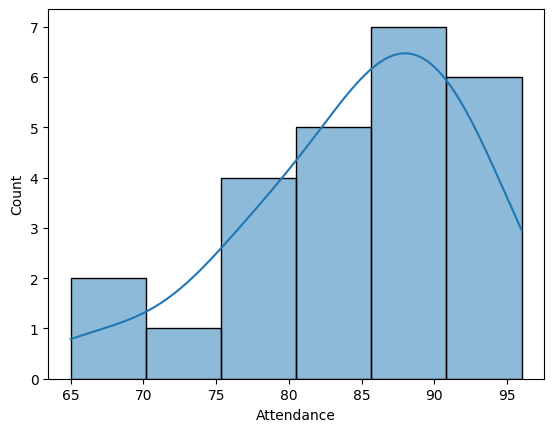

In [59]:
sns.histplot(df['Attendance'], kde=True)